In [99]:
import yt
import numpy as np
#from yt.mods import *
from yt.frontends.boxlib.api import NyxDataset, AMReXDataset
from yt.data_objects.time_series import DatasetSeries
import matplotlib.pyplot as plt
from matplotlib import rc_context
from matplotlib.animation import FuncAnimation
from IPython import display

In [100]:
class AMReXDatasetSeries(DatasetSeries):
    _dataset_cls = AMReXDataset

In [101]:
path = "../Outputs/plt0????"
dsLoad = AMReXDatasetSeries(path)

In [102]:
ds = []
for data in dsLoad:
    ds.append(data)

yt : [INFO     ] 2026-08-24 11:06:00,398 Parameters: current_time              = 0.0


yt : [INFO     ] 2026-08-24 11:06:00,398 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2026-08-24 11:06:00,399 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-08-24 11:06:00,399 Parameters: domain_right_edge         = [20. 20. 20.]
yt : [INFO     ] 2026-08-24 11:06:00,419 Parameters: current_time              = 0.01
yt : [INFO     ] 2026-08-24 11:06:00,420 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2026-08-24 11:06:00,420 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-08-24 11:06:00,420 Parameters: domain_right_edge         = [20. 20. 20.]
yt : [INFO     ] 2026-08-24 11:06:00,439 Parameters: current_time              = 0.02
yt : [INFO     ] 2026-08-24 11:06:00,440 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2026-08-24 11:06:00,440 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-08-24 11:06:00,440 Parameters: domain_right_edge       

In [103]:
def _relE (field, dat):
    av = dat.ds.all_data().quantities.weighted_average_quantity("Edens", weight = ("index", "ones"))
    return dat["Edens"]/av
for data in ds:
    data.add_field(("boxlib","EdensRel"), function=_relE, sampling_type="local", units="dimensionless",force_override=True)

TypeError: Received field function <function _relE at 0x7fbf61523250> with invalid signature. Expected exactly 2 positional parameters ('field', 'data'), got ('field', 'dat')

In [112]:
ds_test = ds[20]
ds_test.field_list

[('boxlib', 'Edens'),
 ('boxlib', 'Edens_pr'),
 ('boxlib', 'Egrad'),
 ('boxlib', 'Ekin'),
 ('boxlib', 'Epot'),
 ('boxlib', 'KGf'),
 ('boxlib', 'KGfVpr'),
 ('boxlib', 'KGfdens'),
 ('boxlib', 'KGfpr'),
 ('boxlib', 'KGfv'),
 ('boxlib', 'PhiGrav'),
 ('boxlib', 'PhiGravV_pr'),
 ('boxlib', 'PhiGrav_pr')]

yt : [INFO     ] 2026-08-24 11:07:40,967 xlim = 0.000000 20.000000
yt : [INFO     ] 2026-08-24 11:07:40,968 ylim = 0.000000 20.000000
yt : [INFO     ] 2026-08-24 11:07:40,971 xlim = 0.000000 20.000000
yt : [INFO     ] 2026-08-24 11:07:40,972 ylim = 0.000000 20.000000
yt : [INFO     ] 2026-08-24 11:07:40,973 Making a fixed resolution buffer of (('boxlib', 'Edens_pr')) 800 by 800
/home/lsou343/.local/lib/python3.10/site-packages/unyt/array.py:1949: RuntimeWarning: invalid value encountered in divide
  out_arr = func(
/home/lsou343/.local/lib/python3.10/site-packages/yt/visualization/image_writer.py:269: RuntimeWarning: invalid value encountered in cast
  mapped = np.dstack([(np.interp(buff, x, v) * 255).astype("uint8") for v in lut])



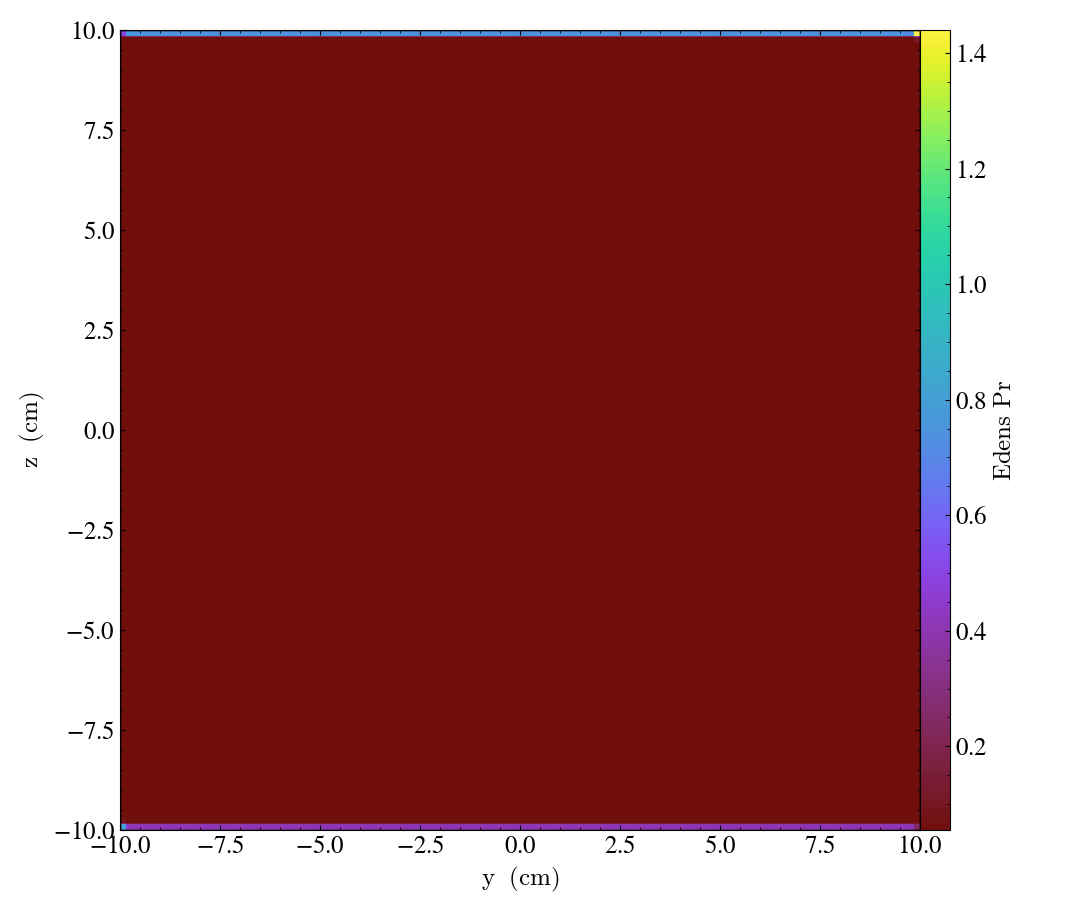

In [118]:
field = "Edens_pr"
plot = yt.SlicePlot(ds[2], "x", field)#, center = [0,0,0])
#plot.set_zlim(("boxlib", "KGfdens"), 1e-13, 2e1)
plot.set_log(field, False)
#plot.show()
plot.annotate_grids()

In [54]:
fig = plot.plots[("boxlib", field)].figure

In [55]:
def animate(i):
    ts = ds[i]
    plot._switch_ds(ts)

In [56]:
animation = FuncAnimation(fig, animate, frames=len(ds))

In [57]:
# Override matplotlib's defaults to get a nicer looking font
with rc_context({"mathtext.fontset": "stix"}):
    #animation.save("animation.mp4")
    video = animation.to_html5_video()
    html = display.HTML(video)
    display.display(html)

/home/lsou343/.local/lib/python3.10/site-packages/unyt/array.py:1949: RuntimeWarning: invalid value encountered in divide
  out_arr = func(
/home/lsou343/.local/lib/python3.10/site-packages/yt/visualization/image_writer.py:269: RuntimeWarning: invalid value encountered in cast
  mapped = np.dstack([(np.interp(buff, x, v) * 255).astype("uint8") for v in lut])


In [58]:
animation.save(f'animation {field}.mp4',fps=4)

/home/lsou343/.local/lib/python3.10/site-packages/unyt/array.py:1949: RuntimeWarning: invalid value encountered in divide
  out_arr = func(
/home/lsou343/.local/lib/python3.10/site-packages/yt/visualization/image_writer.py:269: RuntimeWarning: invalid value encountered in cast
  mapped = np.dstack([(np.interp(buff, x, v) * 255).astype("uint8") for v in lut])


In [37]:
from matplotlib.animation import PillowWriter
writer = PillowWriter(fps=10,
                                 metadata=dict(artist='Me'),
                                 bitrate=1800)
animation.save(f'animation {field}.gif', writer=writer)


/home/lsou343/.local/lib/python3.10/site-packages/unyt/array.py:1949: RuntimeWarning: invalid value encountered in divide
  out_arr = func(
/home/lsou343/.local/lib/python3.10/site-packages/yt/visualization/image_writer.py:269: RuntimeWarning: invalid value encountered in cast
  mapped = np.dstack([(np.interp(buff, x, v) * 255).astype("uint8") for v in lut])


yt : [INFO     ] 2026-08-10 11:16:19,706 xlim = 0.000000 20.000000
yt : [INFO     ] 2026-08-10 11:16:19,706 ylim = 0.000000 20.000000
yt : [INFO     ] 2026-08-10 11:16:19,709 xlim = 0.000000 20.000000
yt : [INFO     ] 2026-08-10 11:16:19,710 ylim = 0.000000 20.000000
yt : [INFO     ] 2026-08-10 11:16:19,711 Making a fixed resolution buffer of (('boxlib', 'PhiGrav_pr')) 800 by 800
/home/lsou343/.local/lib/python3.10/site-packages/unyt/array.py:1949: RuntimeWarning: invalid value encountered in divide
  out_arr = func(
/home/lsou343/.local/lib/python3.10/site-packages/yt/visualization/image_writer.py:269: RuntimeWarning: invalid value encountered in cast
  mapped = np.dstack([(np.interp(buff, x, v) * 255).astype("uint8") for v in lut])



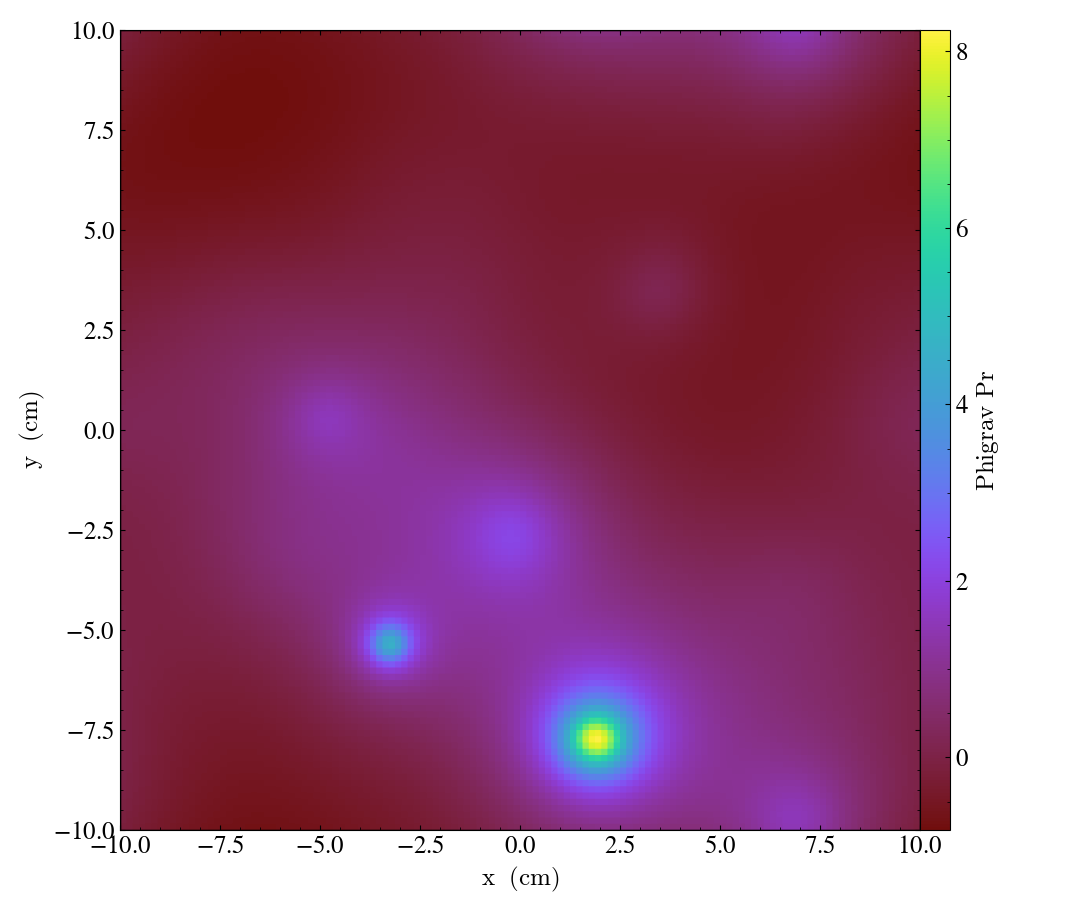

In [31]:
ds_check = ds[-1]

plot = yt.SlicePlot(ds_check, "z", field)#, center = [0,0,0])
#plot.set_zlim(("boxlib", "KGfdens"), 1e-13, 2e1)
plot.set_log(field, False)
#plot.show()
sl = plot.annotate_grids()
sl

In [32]:
sl.save()

yt : [INFO     ] 2026-08-10 11:16:23,526 Saving plot plt09800_Slice_z_PhiGrav_pr.png


['plt09800_Slice_z_PhiGrav_pr.png']

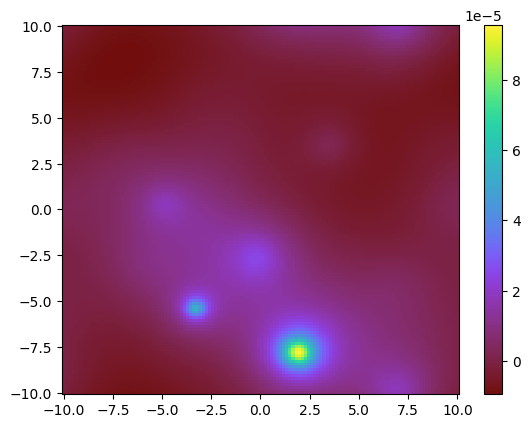

In [38]:
data = ds_check.covering_grid(level=0, left_edge=[0,0,0],dims=[128,128,128])["boxlib", "PhiGrav_pr"]
data = np.array(data)
coef = (6.82239161348826 * 4.300630e+01) ** 2
data /= coef
xs = np.linspace(-10,10,128)
x,y = np.meshgrid(xs,xs,indexing='ij')
plt.pcolormesh(x,y,data[:,:,64], cmap="arbre")
plt.colorbar()
plt.savefig("plt09800_Slice_z_PhiGrav.png",dpi=300)

### Test $\rho$

In [73]:
newt_grad = np.array([3.026388e+00, 5.819476e+00, 6.250378e+01, 3.893255e+02, 1.547635e+03, 4.757839e+03, 1.245846e+04, 2.932945e+04, 6.425342e+04, 1.343138e+05, 2.736203e+05, 5.548838e+05, 
                      1.149668e+06, 2.526604e+06, 6.219892e+06, 1.707285e+07, 2.503389e+07, 1.225490e+08, 7.071238e+17, 3.855895e+80])
newt_kin = np.array([5.901346e+02, 1.441439e+03, 9.894920e+03, 3.441194e+04, 8.680547e+04, 1.866871e+05, 3.672620e+05, 6.872386e+05, 1.256354e+06, 2.294625e+06, 4.284359e+06, 8.412957e+06, 
                     1.809503e+07, 4.538328e+07, 1.448897e+08, 5.786037e+08, 1.355162e+09, 1.056940e+10, 7.561757e+19, 1.190282e+82])
newt_pot = np.array([1.152193e+05, 1.152722e+05, 1.153245e+05, 1.153759e+05, 1.154261e+05, 1.154741e+05, 1.155179e+05, 1.155526e+05, 1.155629e+05, 1.154974e+05, 1.151959e+05, 1.148773e+05, 
                     1.156197e+05, 1.157542e+05, 1.155801e+05, 1.153353e+05, 1.148185e+05, 1.144284e+05, 1.097072e+05, 5.482669e+13])

comov_grad = np.array([3.026388e+00, 2.984676e+00, 2.861957e+00, 2.665291e+00, 2.405958e+00, 2.098802e+00, 1.761356e+00, 1.412822e+00, 1.072951e+00, 7.608960e-01, 4.941048e-01, 2.873195e-01, 
                       1.517353e-01, 9.437253e-02, 1.176970e-01, 2.195072e-01, 3.930968e-01, 6.276788e-01, 9.090460e-01, 1.220427e+00])
comov_kin = np.array([5.901346e+02, 5.907383e+02, 5.921672e+02, 5.936777e+02, 5.952606e+02, 5.969026e+02, 5.985875e+02, 6.002967e+02, 6.020106e+02, 6.037097e+02, 6.053758e+02, 6.069926e+02, 
                      6.085474e+02, 6.100311e+02, 6.114391e+02, 6.127714e+02, 6.140326e+02, 6.152316e+02, 6.163810e+02, 6.174965e+02])
comov_pot = np.array([1.152193e+05, 1.152724e+05, 1.153255e+05, 1.153786e+05, 1.154317e+05, 1.154848e+05, 1.155380e+05, 1.155912e+05, 1.156444e+05, 1.156976e+05, 1.157508e+05, 1.158041e+05, 
                      1.158574e+05, 1.159107e+05, 1.159640e+05, 1.160174e+05, 1.160707e+05, 1.161241e+05, 1.161775e+05, 1.162309e+05])

Text(0.5, 1.0, 'Standard')

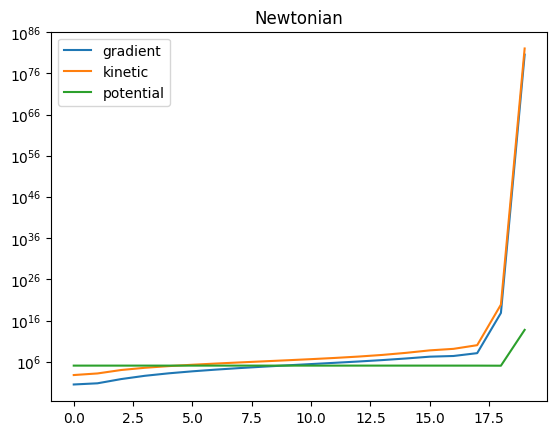

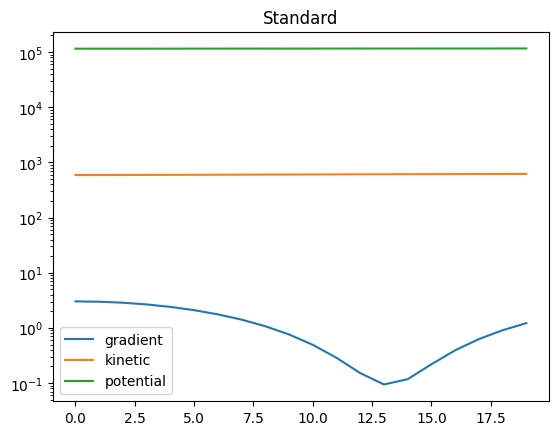

In [74]:
plt.semilogy(newt_grad, label="gradient")
plt.semilogy(newt_kin, label="kinetic")
plt.semilogy(newt_pot, label="potential")
plt.legend()
plt.title("Newtonian")
plt.figure()
plt.semilogy(comov_grad, label="gradient")
plt.semilogy(comov_kin, label="kinetic")
plt.semilogy(comov_pot, label="potential")
plt.legend()
plt.title("Standard")

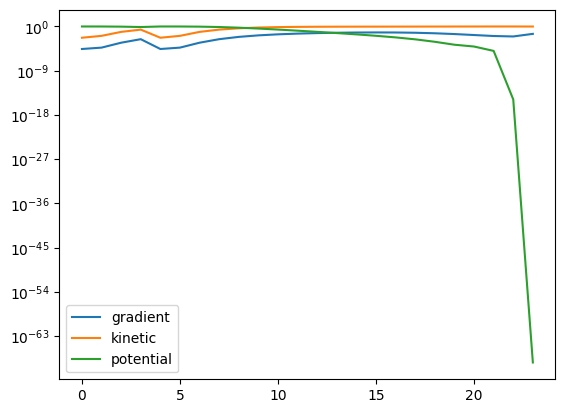

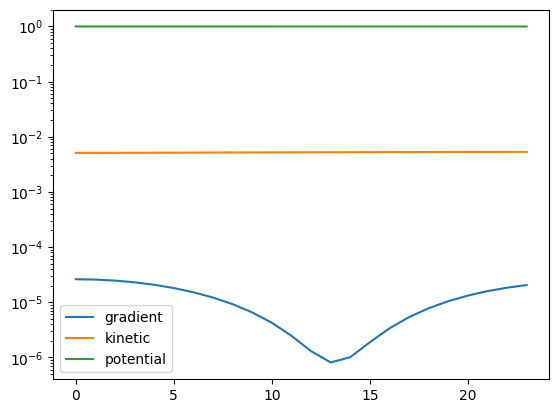

In [67]:
sum = newt_grad + newt_kin + newt_pot
plt.semilogy(newt_grad / sum, label="gradient")
plt.semilogy(newt_kin / sum, label="kinetic")
plt.semilogy(newt_pot / sum, label="potential")
plt.legend()
plt.figure()
sum = comov_grad + comov_kin + comov_pot
plt.semilogy(comov_grad / sum, label="gradient")
plt.semilogy(comov_kin / sum, label="kinetic")
plt.semilogy(comov_pot / sum, label="potential")
plt.legend()

Text(0.5, 1.0, 'Gradient')

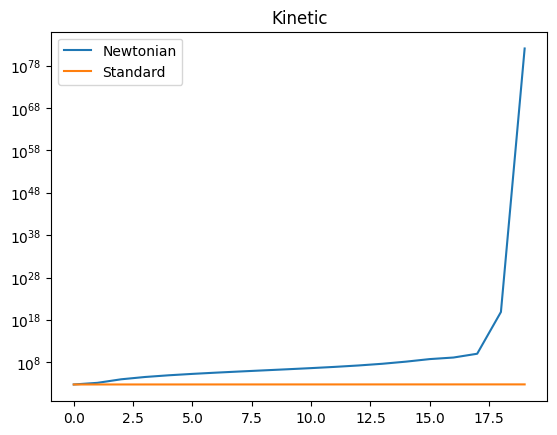

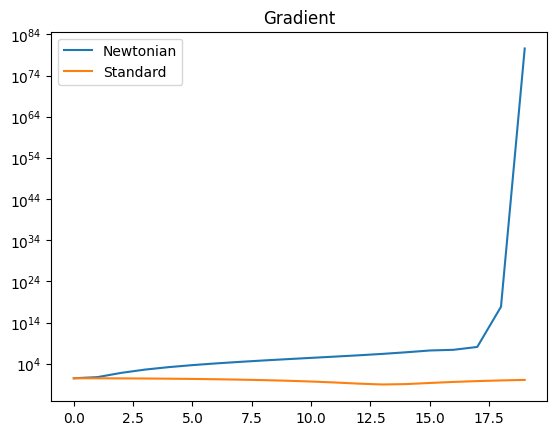

In [79]:
plt.semilogy(newt_kin, label="Newtonian")
plt.semilogy(comov_kin, label="Standard")
plt.legend()
plt.title("Kinetic")
plt.figure()
plt.semilogy(newt_grad, label="Newtonian")
plt.semilogy(comov_grad, label="Standard")
plt.legend()
plt.title("Gradient")